In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded.")

Libraries loaded.


In [33]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# Font
plt.rcParams['font.family'] = 'Georgia'
plt.rcParams['font.size'] = 11

# Colors
BLUE = '#A8BFD0'
SALMON = '#D9B5AE'
PALETTE = [BLUE, SALMON]

# General style
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['axes.facecolor'] = '#FAFAFA'
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelcolor'] = '#333333'
plt.rcParams['xtick.color'] = '#555555'
plt.rcParams['ytick.color'] = '#555555'

print("Style configured.")

Style configured.


In [24]:
df = pd.read_csv("marketing_AB.csv")
print(df.shape)
df.head()

(588101, 7)


,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [25]:
df.info()
print("\nMissing values:\n", df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   Unnamed: 0     588101 non-null  int64
 1   user id        588101 non-null  int64
 2   test group     588101 non-null  str  
 3   converted      588101 non-null  bool 
 4   total ads      588101 non-null  int64
 5   most ads day   588101 non-null  str  
 6   most ads hour  588101 non-null  int64
dtypes: bool(1), int64(4), str(2)
memory usage: 27.5 MB

Missing values:
 Unnamed: 0       0
user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
dtype: int64


In [26]:
print(df['test group'].value_counts())
print("\nConversion counts:\n", df['converted'].value_counts())

test group
ad     564577
psa     23524
Name: count, dtype: int64

Conversion counts:
 converted
False    573258
True      14843
Name: count, dtype: int64


In [27]:
conversion_rate = df.groupby('test group')['converted'].mean()
print(conversion_rate)

test group
ad     0.025547
psa    0.017854
Name: converted, dtype: float64


In [29]:
from scipy import stats

ad_group = df[df['test group'] == 'ad']['converted']
psa_group = df[df['test group'] == 'psa']['converted']

n_ad = len(ad_group)
n_psa = len(psa_group)
p_ad = ad_group.mean()
p_psa = psa_group.mean()

# Pooled proportion
p_pool = (ad_group.sum() + psa_group.sum()) / (n_ad + n_psa)

# Z-statistic
se = np.sqrt(p_pool * (1 - p_pool) * (1/n_ad + 1/n_psa))
z_stat = (p_ad - p_psa) / se
p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"\nConclusion: {'Statistically significant' if p_value < 0.05 else 'Not significant'} at 95% confidence level")

Z-statistic: 7.3701
P-value: 0.000000

Conclusion: Statistically significant at 95% confidence level


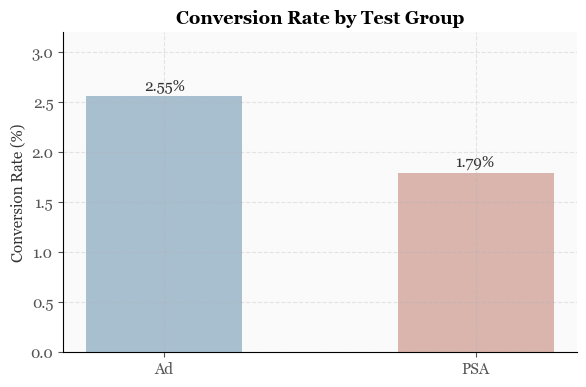

In [34]:
fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(['Ad', 'PSA'], 
              [p_ad * 100, p_psa * 100],
              color=PALETTE, width=0.5, edgecolor='none')

# Add value labels on bars
for bar, val in zip(bars, [p_ad * 100, p_psa * 100]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            f'{val:.2f}%',
            ha='center', va='bottom', fontsize=11, color='#333333')

ax.set_title('Conversion Rate by Test Group')
ax.set_ylabel('Conversion Rate (%)')
ax.set_xlabel('')
ax.set_ylim(0, max(p_ad, p_psa) * 100 * 1.25)

plt.tight_layout()
plt.savefig('conversion_rate_by_group.png', dpi=150, bbox_inches='tight')
plt.show()

In [35]:
confidence = 0.95
z_critical = stats.norm.ppf((1 + confidence) / 2)
margin_of_error = z_critical * se
ci_lower = (p_ad - p_psa) - margin_of_error
ci_upper = (p_ad - p_psa) + margin_of_error

print(f"Difference in conversion rate: {(p_ad - p_psa)*100:.4f}%")
print(f"95% Confidence Interval: ({ci_lower*100:.4f}%, {ci_upper*100:.4f}%)")

Difference in conversion rate: 0.7692%
95% Confidence Interval: (0.5647%, 0.9738%)


In [37]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_conv = df.groupby(['most ads day', 'test group'])['converted'].mean().unstack()
day_conv = day_conv.reindex(day_order)

print(day_conv * 100)

test group          ad       psa
most ads day                    
Monday        3.324120  2.255854
Tuesday       3.044038  1.444788
Wednesday     2.535586  1.575931
Thursday      2.163714  2.023047
Friday        2.246495  1.630292
Saturday      2.130657  1.399580
Sunday        2.461983  2.059497


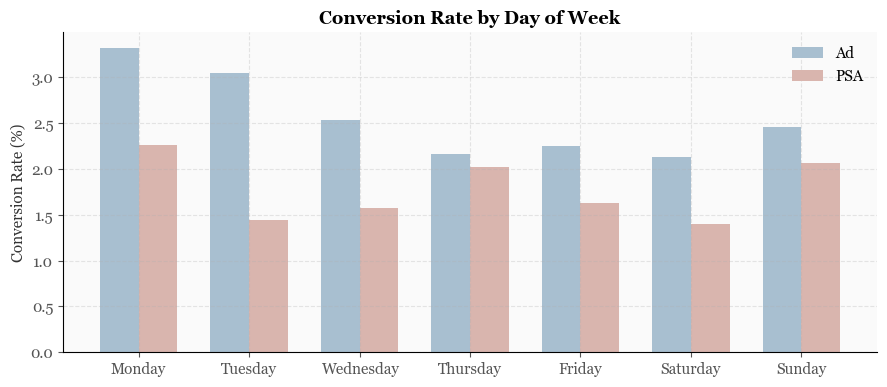

In [39]:
fig, ax = plt.subplots(figsize=(9, 4))

x = range(len(day_order))
width = 0.35

# Draw two sets of bars side by side
ax.bar([i - width/2 for i in x], day_conv['ad'] * 100, 
       width=width, color=BLUE, label='Ad', edgecolor='none')
ax.bar([i + width/2 for i in x], day_conv['psa'] * 100, 
       width=width, color=SALMON, label='PSA', edgecolor='none')

ax.set_xticks(list(x))
ax.set_xticklabels(day_order)
ax.set_title('Conversion Rate by Day of Week')
ax.set_ylabel('Conversion Rate (%)')
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig('conversion_by_day.png', dpi=150, bbox_inches='tight')
plt.show()

In [40]:
# Divide users into buckets based on how many ads they saw
bins = [0, 5, 10, 20, 50, 100, df['total ads'].max()]
labels = ['1–5', '6–10', '11–20', '21–50', '51–100', '100+']

# Create a new column that assigns each user to a bucket
df['ads_bucket'] = pd.cut(df['total ads'], bins=bins, labels=labels)

# Calculate conversion rate per bucket per group
freq_conv = df.groupby(['ads_bucket', 'test group'])['converted'].mean().unstack() * 100

print(freq_conv)

test group         ad        psa
ads_bucket                      
1–5          0.251233   0.279863
6–10         0.485309   0.673499
11–20        0.839995   0.819277
21–50        2.915382   2.177650
51–100      11.631068   5.774420
100+        17.135214  11.881188


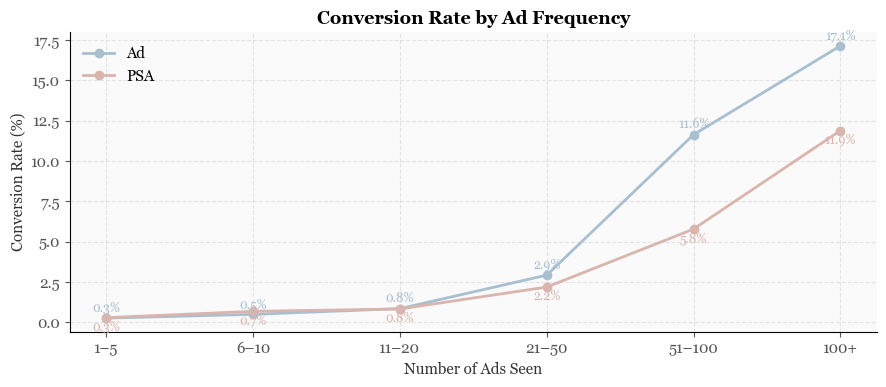

In [41]:
fig, ax = plt.subplots(figsize=(9, 4))

# Plot a line for each group
ax.plot(labels, freq_conv['ad'], 
        color=BLUE, marker='o', linewidth=2, label='Ad')
ax.plot(labels, freq_conv['psa'], 
        color=SALMON, marker='o', linewidth=2, label='PSA')

# Add value labels on each point
for i, (ad_val, psa_val) in enumerate(zip(freq_conv['ad'], freq_conv['psa'])):
    ax.text(i, ad_val + 0.4, f'{ad_val:.1f}%', 
            ha='center', fontsize=9, color=BLUE)
    ax.text(i, psa_val - 0.8, f'{psa_val:.1f}%', 
            ha='center', fontsize=9, color=SALMON)

ax.set_title('Conversion Rate by Ad Frequency')
ax.set_xlabel('Number of Ads Seen')
ax.set_ylabel('Conversion Rate (%)')
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig('conversion_by_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

In [42]:
# Filter ad group only, then calculate conversion rate by day and hour
hour_day_conv = df[df['test group'] == 'ad'].groupby(
    ['most ads day', 'most ads hour'])['converted'].mean().unstack() * 100

# Reorder rows Monday to Sunday
hour_day_conv = hour_day_conv.reindex(day_order)

print(hour_day_conv.shape)
print(hour_day_conv.head())

(7, 24)
most ads hour        0         1         2         3         4         5   \
most ads day                                                                
Monday         1.707317  1.694915  0.705219  1.265823  0.000000  3.260870   
Tuesday        1.963534  1.424051  0.549451  2.083333  2.000000  1.315789   
Wednesday      1.190476  0.838926  0.484653  0.303030  2.000000  0.714286   
Thursday       2.542373  1.881331  1.317716  0.550964  2.752294  2.197802   
Friday         1.982652  1.057402  1.212121  0.388350  1.694915  1.550388   

most ads hour        6         7         8         9   ...        14  \
most ads day                                           ...             
Monday         4.198473  1.842105  3.399668  2.657503  ...  4.487498   
Tuesday        2.262443  2.194787  1.824212  2.364865  ...  3.610108   
Wednesday      1.396648  1.190476  1.661565  1.708108  ...  2.978407   
Thursday       2.105263  1.592040  1.506245  1.589464  ...  2.552346   
Friday         1.212

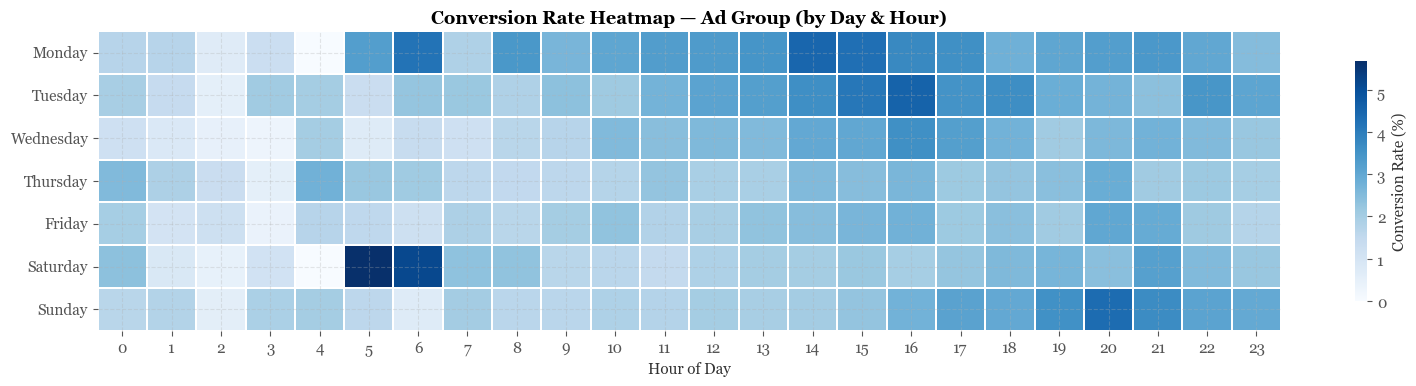

In [43]:
fig, ax = plt.subplots(figsize=(16, 4))

sns.heatmap(hour_day_conv, 
            ax=ax,
            cmap='Blues',          # Blue color scale, deeper = higher conversion
            linewidths=0.3,        # Thin white lines between cells
            linecolor='white',
            annot=False,           # No numbers inside cells (too crowded)
            cbar_kws={'label': 'Conversion Rate (%)', 'shrink': 0.8})

ax.set_title('Conversion Rate Heatmap — Ad Group (by Day & Hour)')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('')

plt.tight_layout()
plt.savefig('heatmap_day_hour.png', dpi=150, bbox_inches='tight')
plt.show()

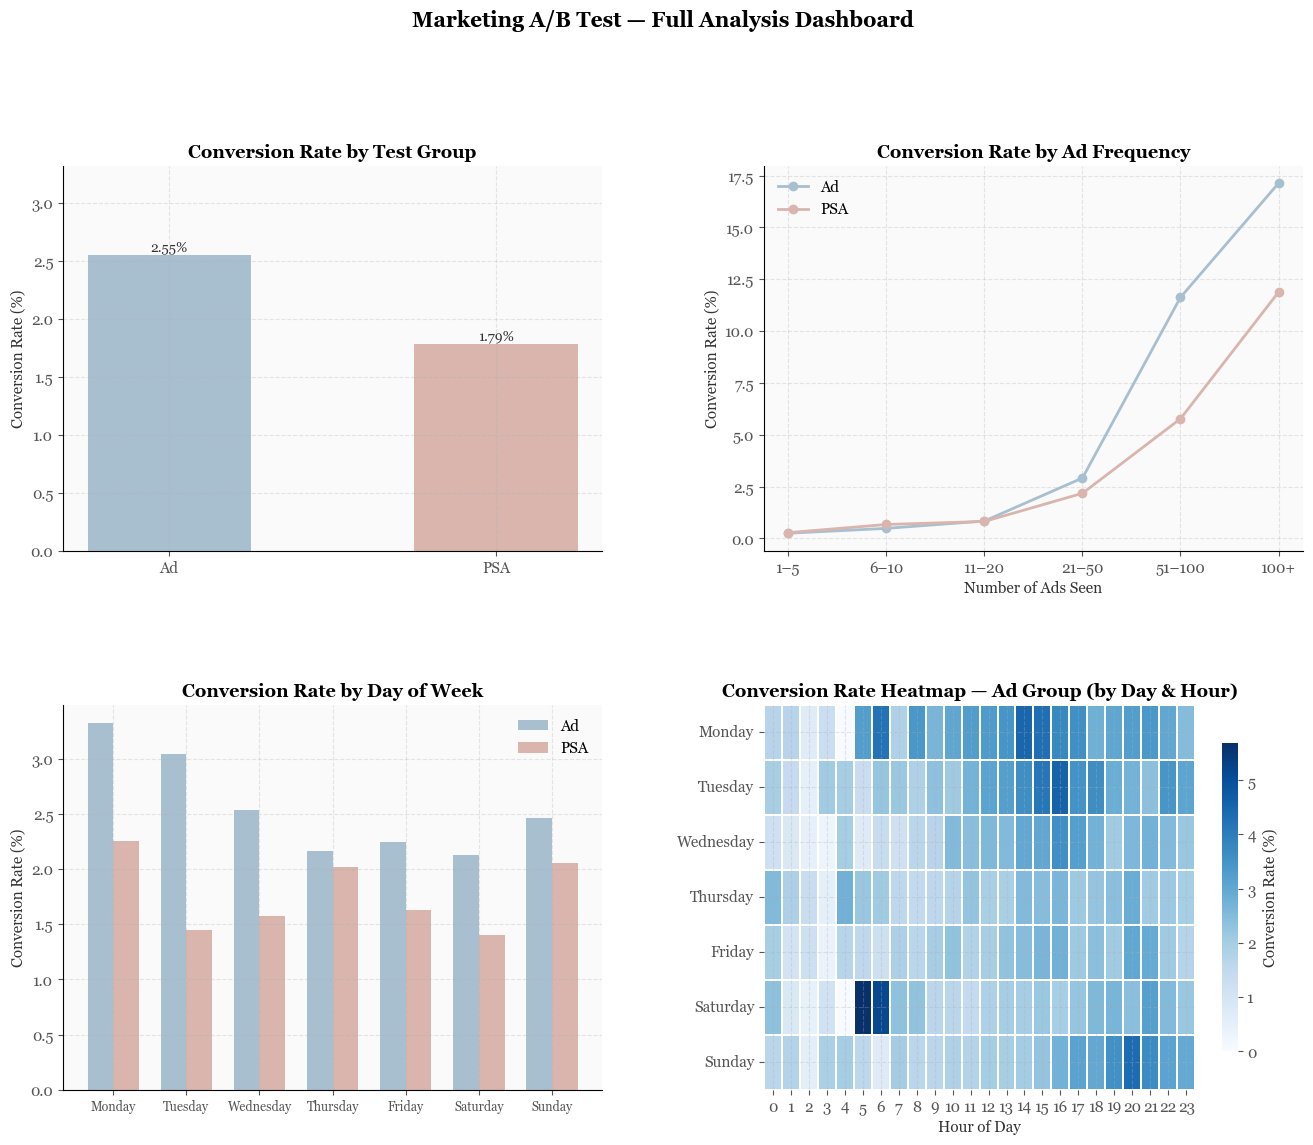

In [46]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.3)

# --- Top left: Conversion rate by group ---
ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.bar(['Ad', 'PSA'], [p_ad * 100, p_psa * 100],
               color=PALETTE, width=0.5, edgecolor='none')
for bar, val in zip(bars, [p_ad * 100, p_psa * 100]):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.03,
             f'{val:.2f}%', ha='center', fontsize=10, color='#333333')
ax1.set_title('Conversion Rate by Test Group')
ax1.set_ylabel('Conversion Rate (%)')
ax1.set_ylim(0, max(p_ad, p_psa) * 100 * 1.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# --- Top right: Conversion rate by frequency ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(labels, freq_conv['ad'], color=BLUE, marker='o', linewidth=2, label='Ad')
ax2.plot(labels, freq_conv['psa'], color=SALMON, marker='o', linewidth=2, label='PSA')
ax2.set_title('Conversion Rate by Ad Frequency')
ax2.set_xlabel('Number of Ads Seen')
ax2.set_ylabel('Conversion Rate (%)')
ax2.legend(frameon=False)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# --- Bottom left: Conversion rate by day ---
ax3 = fig.add_subplot(gs[1, 0])
x = range(len(day_order))
width = 0.35
ax3.bar([i - width/2 for i in x], day_conv['ad'] * 100,
        width=width, color=BLUE, label='Ad', edgecolor='none')
ax3.bar([i + width/2 for i in x], day_conv['psa'] * 100,
        width=width, color=SALMON, label='PSA', edgecolor='none')
ax3.set_xticks(list(x))
ax3.set_xticklabels(day_order, fontsize=9)
ax3.set_title('Conversion Rate by Day of Week')
ax3.set_ylabel('Conversion Rate (%)')
ax3.legend(frameon=False)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# --- Bottom right: Heatmap ---
ax4 = fig.add_subplot(gs[1, 1])
sns.heatmap(hour_day_conv, ax=ax4, cmap='Blues',
            linewidths=0.3, linecolor='white', annot=False,
            cbar_kws={'label': 'Conversion Rate (%)', 'shrink': 0.8})
ax4.set_title('Conversion Rate Heatmap — Ad Group (by Day & Hour)')
ax4.set_xlabel('Hour of Day')
ax4.set_ylabel('')

plt.suptitle('Marketing A/B Test — Full Analysis Dashboard',
             fontsize=15, fontweight='bold', y=1.01)
plt.savefig('dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

In [48]:
summary = """
## Key Findings

#### 1. Ad Effectiveness
The ad group achieved a conversion rate of 2.55% vs. 1.79% for the PSA group.
This represents a 43.1% relative lift, confirmed statistically significant
via two-proportion Z-test (Z=7.37, p<0.0001).

#### 2. Ad Frequency & Conversion
Conversion rate increases monotonically with ad exposure, from 0.25% (1–5 ads)
to 17.1% (100+ ads). However, this correlation likely reflects selection bias:
high-intent users naturally see more ads and convert at higher rates.
Frequency alone should not be treated as a lever for improving conversion.

#### 3. Day-of-Week Patterns
Monday and Tuesday show the highest conversion rates (3.32% and 3.04%),
while Thursday through Saturday are consistently lower (~2.1–2.2%).
The ad group outperforms PSA on every day of the week.

#### 4. Optimal Time Windows
Afternoon to evening hours (14:00–22:00) consistently show the highest
conversion rates across all days. Early morning hours (0:00–4:00) are
the weakest window. Saturday at 5–6am shows anomalous spikes likely
due to small sample size in that cell.

#### Recommendation
Prioritize ad delivery on Monday and Tuesday afternoons (14:00–22:00)
for maximum conversion efficiency. The statistically significant lift
confirms that paid advertising meaningfully outperforms organic PSA exposure.
"""

from IPython.display import Markdown
display(Markdown(summary))


## Key Findings

#### 1. Ad Effectiveness
The ad group achieved a conversion rate of 2.55% vs. 1.79% for the PSA group.
This represents a 43.1% relative lift, confirmed statistically significant
via two-proportion Z-test (Z=7.37, p<0.0001).

#### 2. Ad Frequency & Conversion
Conversion rate increases monotonically with ad exposure, from 0.25% (1–5 ads)
to 17.1% (100+ ads). However, this correlation likely reflects selection bias:
high-intent users naturally see more ads and convert at higher rates.
Frequency alone should not be treated as a lever for improving conversion.

#### 3. Day-of-Week Patterns
Monday and Tuesday show the highest conversion rates (3.32% and 3.04%),
while Thursday through Saturday are consistently lower (~2.1–2.2%).
The ad group outperforms PSA on every day of the week.

#### 4. Optimal Time Windows
Afternoon to evening hours (14:00–22:00) consistently show the highest
conversion rates across all days. Early morning hours (0:00–4:00) are
the weakest window. Saturday at 5–6am shows anomalous spikes likely
due to small sample size in that cell.

#### Recommendation
Prioritize ad delivery on Monday and Tuesday afternoons (14:00–22:00)
for maximum conversion efficiency. The statistically significant lift
confirms that paid advertising meaningfully outperforms organic PSA exposure.
